# Retail ML Project - Preprocessing Notebook
Pipeline: Exploration → Preparation → Transformation

Target: Churn prediction

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
import joblib

from src.utils import load_data, parse_registration_date, feature_engineering, detect_outliers, plot_correlation

In [9]:
# Config
RAW_PATH = '../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv'
PROCESSED_PATH = '../data/processed/processed_data.csv'
TRAIN_TEST_PATHS = {
    'X_train': '../data/train_test/X_train.csv',
    'X_test': '../data/train_test/X_test.csv',
    'y_train': '../data/train_test/y_train.csv',
    'y_test': '../data/train_test/y_test.csv'
}
PCA_VAR = 0.95  # Retain 95% variance
TEST_SIZE = 0.2
RANDOM_STATE = 42


## 1. Load Data & Exploration

In [10]:
df = load_data(RAW_PATH)

print('Initial Shape:', df.shape)
display(df.head())

print(df['Churn'].value_counts())

Loaded data: (4372, 52)
Initial Shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


Churn
0    2918
1    1454
Name: count, dtype: int64


## 2. Data Cleaning & Feature Engineering

In [11]:
# 2. Parse dates and feature engineering
df = parse_registration_date(df)
df = feature_engineering(df)

## 3. Handle Outliers

In [22]:
# Detect outliers (cap them) - use available numerical cols
outlier_cols = ['Recency', 'Frequency', 'MonetaryTotal']
available_outliers = [col for col in outlier_cols if col in df.columns]
if available_outliers:
    outliers = detect_outliers(df, available_outliers, threshold=1.5)
    for col, idxs in outliers.items():
        if idxs:
            df.loc[idxs, col] = df[col].median()  # Cap to median
    print(f"Capped outliers in: {available_outliers}")

Capped outliers in: ['Recency', 'Frequency', 'MonetaryTotal']


## 4. Feature Separation

In [23]:
# Separate X, y (target: Churn)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify numerical/categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Num cols:', len(num_cols), 'Cat cols:', len(cat_cols))
print('Features:', X.shape[1], 'Target shape:', y.shape)

Num cols: 36 Cat cols: 17
Features: 57 Target shape: (4372,)


## 5. Train/Test Split (NO DATA LEAKAGE)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Preprocessing Pipeline

In [25]:
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

## 7. Fit ONLY on Train (Important)

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

joblib.dump(preprocessor, '../models/preprocessor.pkl')

['../models/preprocessor.pkl']

## 8. PCA (Dimensionality Reduction)

In [27]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

joblib.dump(pca, '../models/pca.pkl')

print('Components:', X_train_pca.shape[1])
print('Explained variance:', pca.explained_variance_ratio_.sum())

Components: 1
Explained variance: 0.9999123296595928


## 9. Save Data

In [28]:
os.makedirs('../data/train_test', exist_ok=True)

pd.DataFrame(X_train_pca).to_csv('../data/train_test/X_train.csv', index=False)
pd.DataFrame(X_test_pca).to_csv('../data/train_test/X_test.csv', index=False)
y_train.to_csv('../data/train_test/y_train.csv', index=False)
y_test.to_csv('../data/train_test/y_test.csv', index=False)

## 10. Correlation Analysis

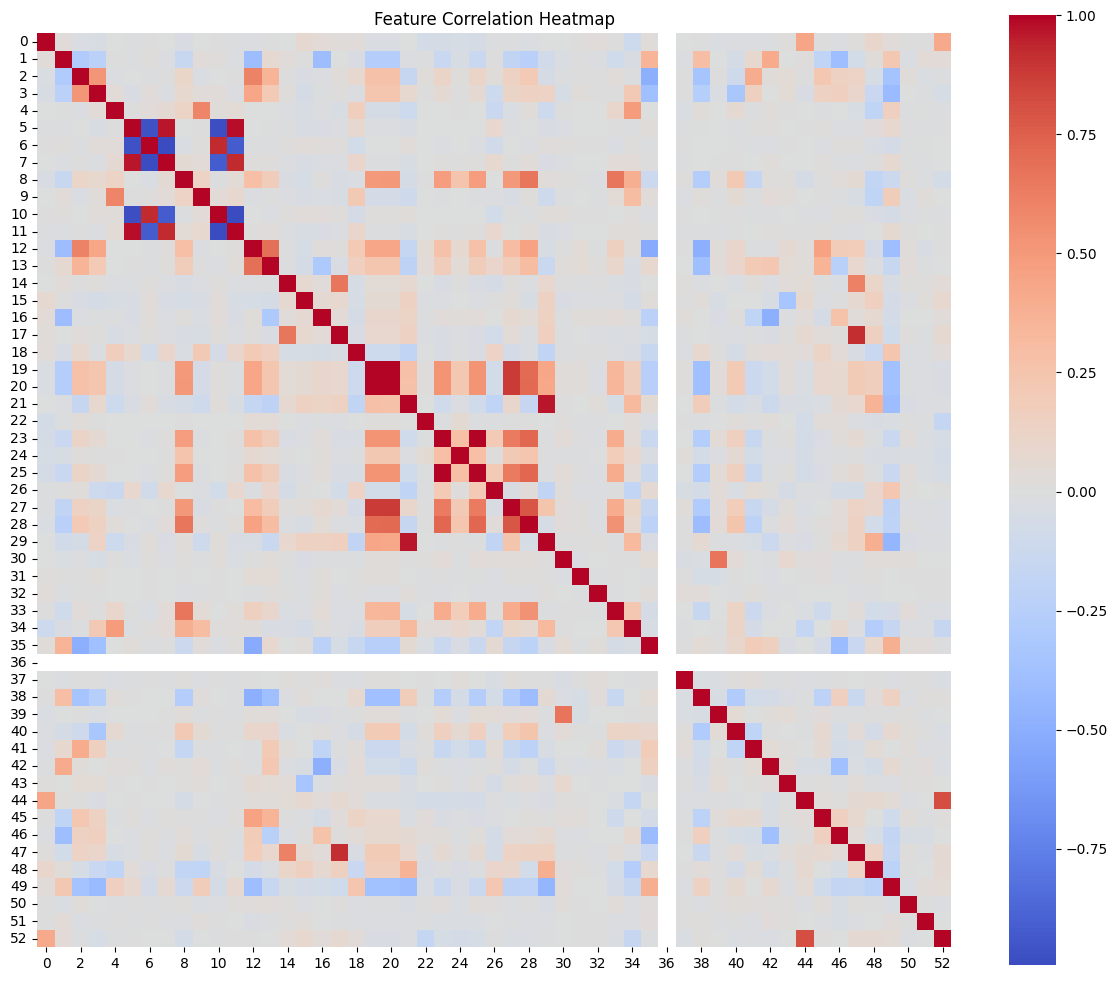

In [29]:
plot_correlation(pd.DataFrame(X_train_processed))